# **Oil Well Location Optimization for OilyGiant**

### **The Problem**

OilyGiant needs to determine the most profitable region for deploying **200 new oil wells** across three exploration sites while ensuring the probability of financial loss remains below the company's maximum acceptable threshold of **2.5%**.

### **Project Significance**

Selecting the wrong exploration region could result in millions of dollars in unnecessary investment losses. This analysis combines predictive modeling with financial risk assessment to support data-driven capital allocation decisions.

### **Data & Target**

The project uses geological exploration data from **three independent regions**, each containing anonymized geological features (`f0`, `f1`, `f2`) and the corresponding oil reserve volume (`product`), which serves as the prediction target.

### **Analysis Pipeline**

1. **Data Exploration & Cleaning:** Inspect data quality, remove duplicate well identifiers, and analyze target distributions.
2. **Predictive Modeling:** Train and evaluate a Linear Regression model independently for each region to estimate oil reserve volumes.
3. **Business Evaluation:** Estimate potential profits by selecting the top 200 predicted wells in each region.
4. **Risk Assessment:** Apply Bootstrap simulations (1,000 iterations) to estimate average profits, confidence intervals, and the probability of financial loss.

### **Modeling**

`Linear Regression` was selected as the predictive model because the objective is to estimate a **continuous target variable** (oil reserve volume). Model performance was then integrated into a business-oriented evaluation framework combining profitability analysis with statistical risk simulation.

### **Evaluation**

Predictive performance was evaluated using **Root Mean Squared Error (RMSE)**, while investment decisions were based on **expected profit**, **95% confidence intervals**, and the **probability of financial loss** obtained through Bootstrap simulations.

### **Key Takeaways**

* **Region 1** achieved the highest expected profit while maintaining the **lowest probability of financial loss (0.5%)**, making it the recommended investment region.
* **Predictive accuracy alone was not sufficient** for decision-making; combining model performance with financial risk produced a more reliable recommendation.
* **Bootstrap simulation** provided a realistic assessment of investment uncertainty, preventing conclusions based solely on idealized prediction scenarios.

### **Next Steps**

Future improvements could include incorporating additional geological variables, spatial coordinates, and external economic factors such as fluctuating oil prices. Exploring more advanced regression models (e.g., Random Forest, Gradient Boosting, or LightGBM) could also help capture non-linear relationships within the geological data.

## **1. Environment Setup**

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model development
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Model evaluation
from sklearn.metrics import mean_squared_error

# Global reproducibility configuration
RANDOM_STATE = 42

## **2. Exploratory Data Analysis (EDA)**
### **2.1. Data Loading**

In [2]:
df0 = pd.read_csv('../data/geo_data_0.csv')
df1 = pd.read_csv('../data/geo_data_1.csv')
df2 = pd.read_csv('../data/geo_data_2.csv')

### **2.2. Initial Data Inspection**

Before building predictive models, it is essential to verify the overall quality and consistency of the datasets. This step focuses on identifying the structure of the data, missing values, duplicate identifiers, and basic statistical patterns that could influence model performance.

In [3]:
# Store all regional datasets for iterative analysis
df_list = [df0, df1, df2]

# Preview the first observations from each region
for df in df_list:
    print(df.head(), "\n")

      id        f0        f1        f2     product
0  txEyH  0.705745 -0.497823  1.221170  105.280062
1  2acmU  1.334711 -0.340164  4.365080   73.037750
2  409Wp  1.022732  0.151990  1.419926   85.265647
3  iJLyR -0.032172  0.139033  2.978566  168.620776
4  Xdl7t  1.988431  0.155413  4.751769  154.036647 

      id         f0         f1        f2     product
0  kBEdx -15.001348  -8.276000 -0.005876    3.179103
1  62mP7  14.272088  -3.475083  0.999183   26.953261
2  vyE1P   6.263187  -5.948386  5.001160  134.766305
3  KcrkZ -13.081196 -11.506057  4.999415  137.945408
4  AHL4O  12.702195  -8.147433  5.004363  134.766305 

      id        f0        f1        f2     product
0  fwXo0 -1.146987  0.963328 -0.828965   27.758673
1  WJtFt  0.262778  0.269839 -2.530187   56.069697
2  ovLUW  0.194587  0.289035 -5.586433   62.871910
3  q6cA6  2.236060 -0.553760  0.930038  114.572842
4  WPMUX -0.515993  1.716266  5.899011  149.600746 



Three independent datasets were provided, each representing a different exploration region. Every dataset contains anonymized geological features (`f0`, `f1`, `f2`) together with the observed reserve volume (`product`), which will serve as the prediction target throughout the project.

In [4]:
def inspect_dataset(df, region_name):
    """Display key quality metrics for a regional dataset."""

    print(f"\n{'-'*50}")
    print(region_name)
    print(f"{'-'*50}")

    print(f"Shape: {df.shape}")
    print(f"\nMissing values:\n{df.isnull().sum()}")

    print(f"\nDuplicate IDs: {df['id'].duplicated().sum()}")

    print(f"\nSummary statistics:")
    display(df.describe())

In [5]:
for idx, dataset in enumerate(df_list):
    inspect_dataset(dataset, f"Region {idx}")


--------------------------------------------------
Region 0
--------------------------------------------------
Shape: (100000, 5)

Missing values:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

Duplicate IDs: 10

Summary statistics:


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347



--------------------------------------------------
Region 1
--------------------------------------------------
Shape: (100000, 5)

Missing values:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

Duplicate IDs: 4

Summary statistics:


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408



--------------------------------------------------
Region 2
--------------------------------------------------
Shape: (100000, 5)

Missing values:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

Duplicate IDs: 4

Summary statistics:


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


### *Key findings*

* **No Missing Data**
* **ID Duplicates** $\rightarrow$ *Action:* Immediate removal of redundant records to prevent them from influencing model training. Since duplicate records account for only a tiny fraction of the data, their removal is not expected to materially affect model performance.

* **Regional distributions differ considerably:** Region 1 presents a substantially lower average reserve volume than Regions 0 and 2, suggesting meaningful geological differences that may impact predictive performance and profitability.
* **Feature ranges remain comparable across datasets**, allowing the same preprocessing and modeling strategy to be applied consistently throughout the analysis.

### **2.3. Data Cleaning**

In [6]:
def remove_duplicate_ids(df):
    """
    Remove duplicated well identifiers while preserving
    the first occurrence.
    """
    return df.drop_duplicates(subset="id").reset_index(drop=True)

In [7]:
clean_datasets = []
cleaning_summary = []

for idx, dataset in enumerate(df_list):

    cleaned_df = remove_duplicate_ids(dataset)
    clean_datasets.append(cleaned_df)

    duplicate_count = dataset["id"].duplicated().sum()

    cleaning_summary.append({
        "Region": idx,
        "Original Rows": len(dataset),
        "Duplicate IDs Removed": duplicate_count,
        "Final Rows": len(cleaned_df)
    })

cleaning_summary = pd.DataFrame(cleaning_summary)

cleaning_summary

,Region,Original Rows,Duplicate IDs Removed,Final Rows
0,0,100000,10,99990
1,1,100000,4,99996
2,2,100000,4,99996


In [8]:
# Replace the original datasets with their cleaned versions
df0, df1, df2 = clean_datasets

### **2.4. Target Distribution Analysis**

Before training predictive models, it is important to understand how the target variable (`product`) is distributed across the three exploration regions. Differences in distribution shape, variability, or granularity may influence both model performance and the interpretation of prediction errors.

In [9]:
def plot_target_distribution(datasets):
    """
    Plot the distribution of the target variable for each region.
    """

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

    for idx, (dataset, ax) in enumerate(zip(datasets, axes)):
        sns.histplot(
            data=dataset,
            x="product",
            bins=50,
            color="teal",
            edgecolor="white",
            ax=ax
        )

        ax.set_title(f"Region {idx}")
        ax.set_xlabel("Reserve Volume")
        ax.set_ylabel("Frequency")

    plt.suptitle(
        "Distribution of Oil Reserve Volumes by Region",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

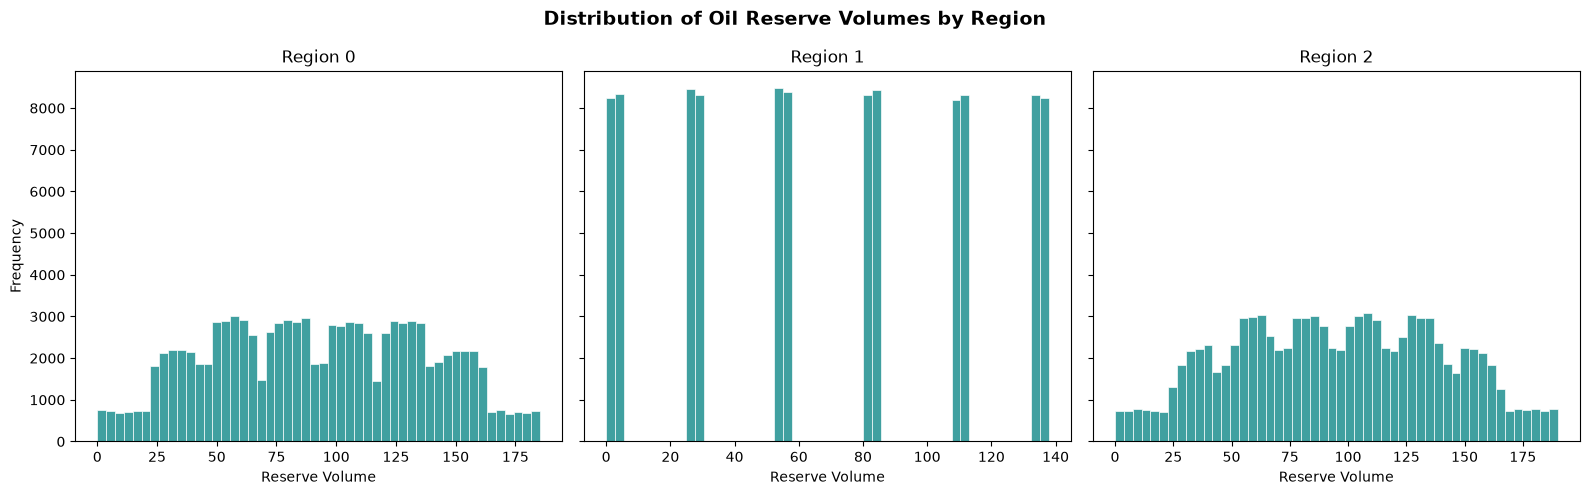

In [10]:
plot_target_distribution(clean_datasets)

In [11]:
region_1_unique = df1["product"].nunique()

print(f"Unique reserve volume values in Region 1: {region_1_unique}")

Unique reserve volume values in Region 1: 12


### *Key Findings*

- **Regions 0 and 2 exhibit continuous, multi-modal distributions**, suggesting more complex geological variability and a broader range of reserve volumes.

- **Region 1 displays a highly discrete target distribution**, with only 12 unique reserve volume values. This pattern is atypical for real-world continuous measurements and suggests that the dataset may have been discretized or synthetically generated.

- Because Region 1 contains substantially fewer target values, **Linear Regression is expected to achieve a lower prediction error (RMSE)** than in the other two regions. This anticipated improvement should be interpreted cautiously, as it reflects the characteristics of the dataset rather than necessarily indicating a superior predictive model.

- These distributional differences will be considered when comparing model performance across regions.

## **3. Predictive Modeling**
### **3.1. Linear Regression**

Linear Regression was selected as the baseline predictive model because the project requires estimating a continuous target variable (oil reserve volume). Beyond its simplicity and interpretability, it provides a strong benchmark for comparing the predictive behavior across the three exploration regions.

To ensure reproducibility, all train-validation splits use a fixed `RANDOM_STATE`.

In [12]:
def train_and_evaluate_region(df, region_name):
    """
    Train and evaluate a Linear Regression model
    for a single exploration region.
    """

    # Features and target
    X = df.drop(columns=["id", "product"])
    y = df["product"]

    # Train-validation split
    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=RANDOM_STATE
    )

    # Model training
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predictions
    predictions = model.predict(X_valid)

    # Evaluation
    rmse = np.sqrt(mean_squared_error(y_valid, predictions))
    average_prediction = predictions.mean()

    return (
        pd.Series(predictions, index=y_valid.index),
        y_valid,
        rmse,
        average_prediction
    )

In [13]:
evaluation_summary = []

model_results = {}

for idx, dataset in enumerate(clean_datasets):

    predictions, actuals, rmse, avg_prediction = train_and_evaluate_region(
        dataset,
        f"Region {idx}"
    )

    model_results[idx] = (predictions, actuals)

    evaluation_summary.append({
        "Region": f"Region {idx}",
        "RMSE": rmse,
        "Avg. Predicted": avg_prediction,
        "Avg. Actual": actuals.mean()
    })

evaluation_summary = pd.DataFrame(evaluation_summary)

evaluation_summary

,Region,RMSE,Avg. Predicted,Avg. Actual
0,Region 0,37.685089,92.609840,92.388766
1,Region 1,0.892827,68.577035,68.583616
2,Region 2,40.080822,94.934787,95.254637


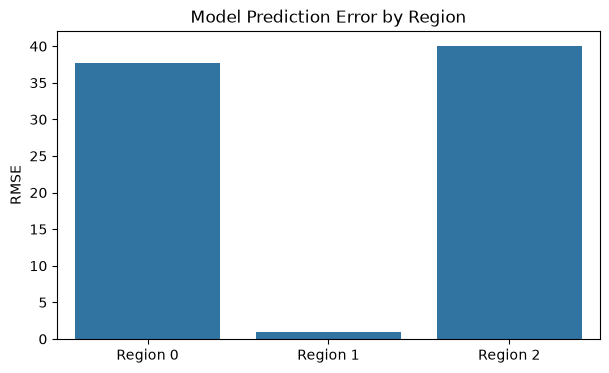

In [14]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=evaluation_summary,
    x="Region",
    y="RMSE"
)

plt.title("Model Prediction Error by Region")
plt.ylabel("RMSE")
plt.xlabel("")

plt.show()

### *Key Findings*

- **Region 1 achieved the lowest RMSE**, indicating substantially higher predictive accuracy than the other two regions.

- This result should be interpreted with caution. As observed during the exploratory analysis, Region 1 contains only a limited number of unique target values, making the prediction task considerably simpler than in Regions 0 and 2.

- **Regions 0 and 2 exhibit higher prediction errors**, which is expected given their more continuous and variable reserve distributions. These datasets better reflect the uncertainty typically encountered in real-world geological exploration.

- Across all regions, the average predicted reserve volume closely matches the average observed reserve volume, suggesting that the model is well calibrated and does not introduce systematic prediction bias.

- Although Region 1 provides the highest predictive accuracy, **model performance alone is not sufficient to determine the best investment region**. Economic profitability and financial risk will be evaluated in the next stage through profit calculations and bootstrap simulations.

## **4. Profitability Analysis**
### **4.1 Financial Assumptions**
The predictive model estimates reserve volumes, but investment decisions ultimately depend on financial performance. Before estimating profits, the project's economic assumptions are defined according to the business requirements.

In [15]:
TOTAL_BUDGET = 100_000_000
SELECTED_WELLS = 200
REVENUE_PER_UNIT = 4_500

### **4.2 Break-even Analysis**

In [16]:
break_even_volume = (
    TOTAL_BUDGET /
    SELECTED_WELLS /
    REVENUE_PER_UNIT
)

break_even_summary = evaluation_summary.copy()

break_even_summary["Break-even Volume"] = break_even_volume
break_even_summary["Difference"] = (
    break_even_summary["Avg. Predicted"] -
    break_even_volume
)

break_even_summary

,Region,RMSE,Avg. Predicted,Avg. Actual,Break-even Volume,Difference
0,Region 0,37.685089,92.609840,92.388766,111.111111,-18.501271
1,Region 1,0.892827,68.577035,68.583616,111.111111,-42.534077
2,Region 2,40.080822,94.934787,95.254637,111.111111,-16.176324


### *Key Findings*
* The break-even threshold is **`111.11` thousand barrels per well.**
* **None of the regions reaches this value** when considering the average predicted reserve volume.
* Consequently, **randomly selecting wells would not be economically viable.**
* This justifies using the predictive model to **prioritize only the most promising wells.**

### **4.3 Profit Estimation**
Using the predicted reserve volumes, the model ranks wells according to their expected productivity. Following the project requirements, only the **200 highest-ranked wells** are selected, and their **actual reserve volumes** are used to estimate the potential profit.

This represents an **idealized scenario**, assuming that the predictive model always identifies the most productive wells available.

In [17]:
def calculate_profit(actual_reserves, predicted_reserves, well_count):
    """
    Calculate the net profit obtained by selecting the wells
    with the highest predicted reserve volumes.
    """

    top_predictions = predicted_reserves.sort_values(ascending=False)

    selected_indices = top_predictions.index[:well_count]

    selected_reserves = actual_reserves.loc[selected_indices]

    revenue = selected_reserves.sum() * REVENUE_PER_UNIT

    profit = revenue - TOTAL_BUDGET

    return profit

In [18]:
profit_summary = []

for idx in range(3):

    predictions, actuals = model_results[idx]

    top_predictions = predictions.sort_values(ascending=False).head(SELECTED_WELLS)

    selected_reserves = actuals.loc[top_predictions.index]

    total_reserves = selected_reserves.sum()

    estimated_profit = calculate_profit(
        actuals,
        predictions,
        SELECTED_WELLS
    )

    profit_summary.append({
        "Region": f"Region {idx}",
        "Selected Reserves": total_reserves,
        "Estimated Profit (USD)": estimated_profit
    })

profit_summary = pd.DataFrame(profit_summary)

profit_summary

,Region,Selected Reserves,Estimated Profit (USD)
0,Region 0,29930.066194,3.468530e+07
1,Region 1,27589.081548,2.415087e+07
2,Region 2,27548.028891,2.396613e+07


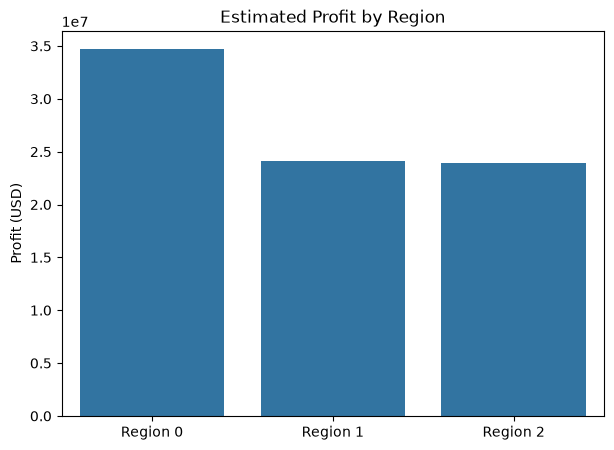

In [19]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=profit_summary,
    x="Region",
    y="Estimated Profit (USD)"
)

plt.title("Estimated Profit by Region")
plt.ylabel("Profit (USD)")
plt.xlabel("")

plt.show()

### *Key Findings*

- Selecting only the highest-ranked wells dramatically improves the financial outlook compared to considering the regional averages.
- Under this idealized scenario, **all three regions become profitable**.
- **Region 0 achieves the highest estimated profit**, followed by Regions 1 and 2.
- Because this analysis assumes perfect well ranking, it should be interpreted as an optimistic upper bound rather than a realistic investment outcome.

### **4.4. Risk Simulation (Bootstrapping)**
The previous analysis assumes that the predictive model always selects the best-performing wells. In reality, exploration outcomes are uncertain.

To quantify this uncertainty, **1,000 bootstrap simulations** are performed for each region. Each simulation randomly samples exploration sites, estimates the resulting profit, and measures both the expected return and the probability of financial loss.

In [20]:
def perform_bootstrap_simulation(actual_reserves, predicted_reserves):

    random_state = np.random.RandomState(RANDOM_STATE)

    profits = []

    for _ in range(1000):

        sampled_actual = actual_reserves.sample(
            n=500,
            replace=True,
            random_state=random_state
        )

        sampled_predictions = predicted_reserves.loc[sampled_actual.index]

        profit = calculate_profit(
            sampled_actual,
            sampled_predictions,
            SELECTED_WELLS
        )

        profits.append(profit)

    profits = pd.Series(profits)

    mean_profit = profits.mean()

    lower_ci = profits.quantile(.025)
    upper_ci = profits.quantile(.975)

    loss_risk = (profits < 0).mean() * 100

    return mean_profit, lower_ci, upper_ci, loss_risk

In [21]:
bootstrap_summary = []

for idx in range(3):

    predictions, actuals = model_results[idx]

    mean_profit, lower_ci, upper_ci, loss_risk = (
        perform_bootstrap_simulation(
            actuals,
            predictions
        )
    )

    bootstrap_summary.append({
        "Region": f"Region {idx}",
        "Mean Profit (USD)": mean_profit,
        "95% CI Lower": lower_ci,
        "95% CI Upper": upper_ci,
        "Loss Risk (%)": loss_risk,
        "Status": (
            "Accept"
            if loss_risk < 2.5
            else "Reject"
        )
    })

bootstrap_summary = pd.DataFrame(bootstrap_summary)

bootstrap_summary

,Region,Mean Profit (USD),95% CI Lower,95% CI Upper,Loss Risk (%),Status
0,Region 0,6.203149e+06,2.764735e+05,1.227233e+07,1.9,Accept
1,Region 1,6.402521e+06,1.516177e+06,1.222629e+07,0.5,Accept
2,Region 2,5.982811e+06,-1.773580e+05,1.271980e+07,3.1,Reject


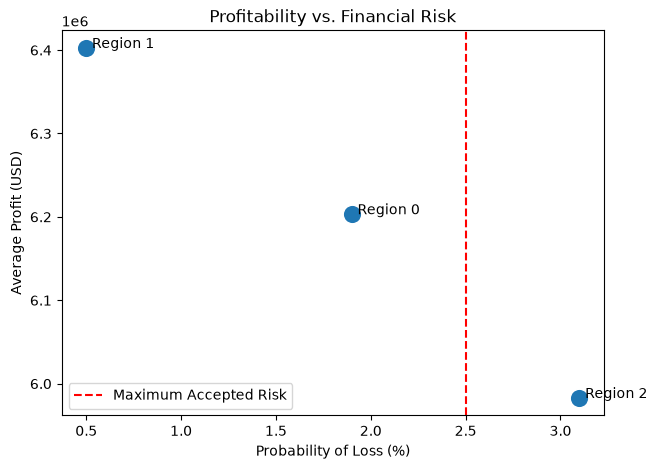

In [22]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=bootstrap_summary,
    x="Loss Risk (%)",
    y="Mean Profit (USD)",
    s=180
)

for _, row in bootstrap_summary.iterrows():
    plt.text(
        row["Loss Risk (%)"] + 0.03,
        row["Mean Profit (USD)"],
        row["Region"]
    )

plt.axvline(
    2.5,
    color="red",
    linestyle="--",
    label="Maximum Accepted Risk"
)

plt.title("Profitability vs. Financial Risk")
plt.xlabel("Probability of Loss (%)")
plt.ylabel("Average Profit (USD)")

plt.legend()

plt.show()

### *Key Findings*

- **Region 1 delivers the highest expected profit while maintaining the lowest probability of financial loss.**
- Region 0 remains profitable but exhibits greater uncertainty.
- Region 2 exceeds the company's maximum acceptable loss threshold (2.5%) and is therefore excluded.
- Considering both profitability and financial risk, **Region 1 represents the strongest investment opportunity.**

## **5. Executive Summary**

In [23]:
executive_summary = (
    evaluation_summary
    .merge(
        profit_summary,
        on="Region"
    )
    .merge(
        bootstrap_summary,
        on="Region"
    )
)

executive_summary

,Region,RMSE,Avg. Predicted,Avg. Actual,Selected Reserves,Estimated Profit (USD),Mean Profit (USD),95% CI Lower,95% CI Upper,Loss Risk (%),Status
0,Region 0,37.685089,92.609840,92.388766,29930.066194,3.468530e+07,6.203149e+06,2.764735e+05,1.227233e+07,1.9,Accept
1,Region 1,0.892827,68.577035,68.583616,27589.081548,2.415087e+07,6.402521e+06,1.516177e+06,1.222629e+07,0.5,Accept
2,Region 2,40.080822,94.934787,95.254637,27548.028891,2.396613e+07,5.982811e+06,-1.773580e+05,1.271980e+07,3.1,Reject


### **Final Recommendation**

Among the three exploration regions, **Region 1 offers the most attractive balance between predictive reliability, expected profitability, and financial risk**.

Although Region 0 achieves the highest profit under the idealized selection scenario, its higher prediction error introduces greater uncertainty during exploration. Region 2, despite generating competitive returns, exceeds the company's maximum acceptable probability of financial loss.

Considering both the technical performance of the predictive model and the project's business constraints, **Region 1 is the recommended location for deploying the 200 new oil wells.**